# FK07 Telemetry Analysis — SCCA AutoX 10/12/25
Real data from Bosch DARAB export. Run `import_darab.py` first to load data into the API.

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

BASE_URL = 'http://127.0.0.1:8000'

sessions = requests.get(f'{BASE_URL}/sessions/').json()
for s in sessions:
    print(f"ID {s['id']}: {s['session_name']} | {s['vehicle_id']} | {s['driver']} | {s['track']}")

ID 1: 10_12_25_SCCA | FK07 | Noah | SCCA AutoX


In [2]:
SESSION_ID = 1
metrics = requests.get(f'{BASE_URL}/sessions/{SESSION_ID}/telemetry/metrics').json()
pd.DataFrame([metrics]).T.rename(columns={0: 'value'})

,value
session_id,1
session_name,10_12_25_SCCA
total_records,48901
duration_s,4890.0
total_distance_m,13672.5
avg_speed_kmh,8.98
max_speed_kmh,97.75
avg_engine_rpm,3001.5
max_engine_rpm,14785.0
avg_throttle_pct,22.18


## Load Full Session Data

In [3]:
all_records = []
skip = 0
limit = 1000
while True:
    batch = requests.get(f'{BASE_URL}/sessions/{SESSION_ID}/telemetry/?skip={skip}&limit={limit}').json()
    if not batch:
        break
    all_records.extend(batch)
    skip += limit
    print(f'  Loaded {len(all_records):,} records...', end='\r')

df = pd.DataFrame(all_records)
print(f'\nTotal: {len(df):,} records | {df["lap_number"].nunique()} laps')
df.head(3)

  Loaded 48,901 records...
Total: 48,901 records | 29 laps


,xtime,xdist,az,coolant_temp_c,engine_speed_rpm,fuel_pressure_kpa,gps_speed_kmh,lapdist_m,laptime_s,str_whl_angle_deg,throttle_pct,lap_number,id,session_id,recorded_at
0,0.0,0.0,0.995092,20.6,0.0,345.0,0.0,0.0,0.0,197.45,20.0,1,1,1,2026-03-04T06:25:52.330233
1,0.1,0.0,0.992161,20.6,0.0,343.6,0.0,0.0,0.1,197.50,20.0,1,2,1,2026-03-04T06:25:52.330233
2,0.2,0.0,0.996112,20.6,0.0,342.4,0.0,0.0,0.2,197.55,19.9,1,3,1,2026-03-04T06:25:52.330233


## Session Overview

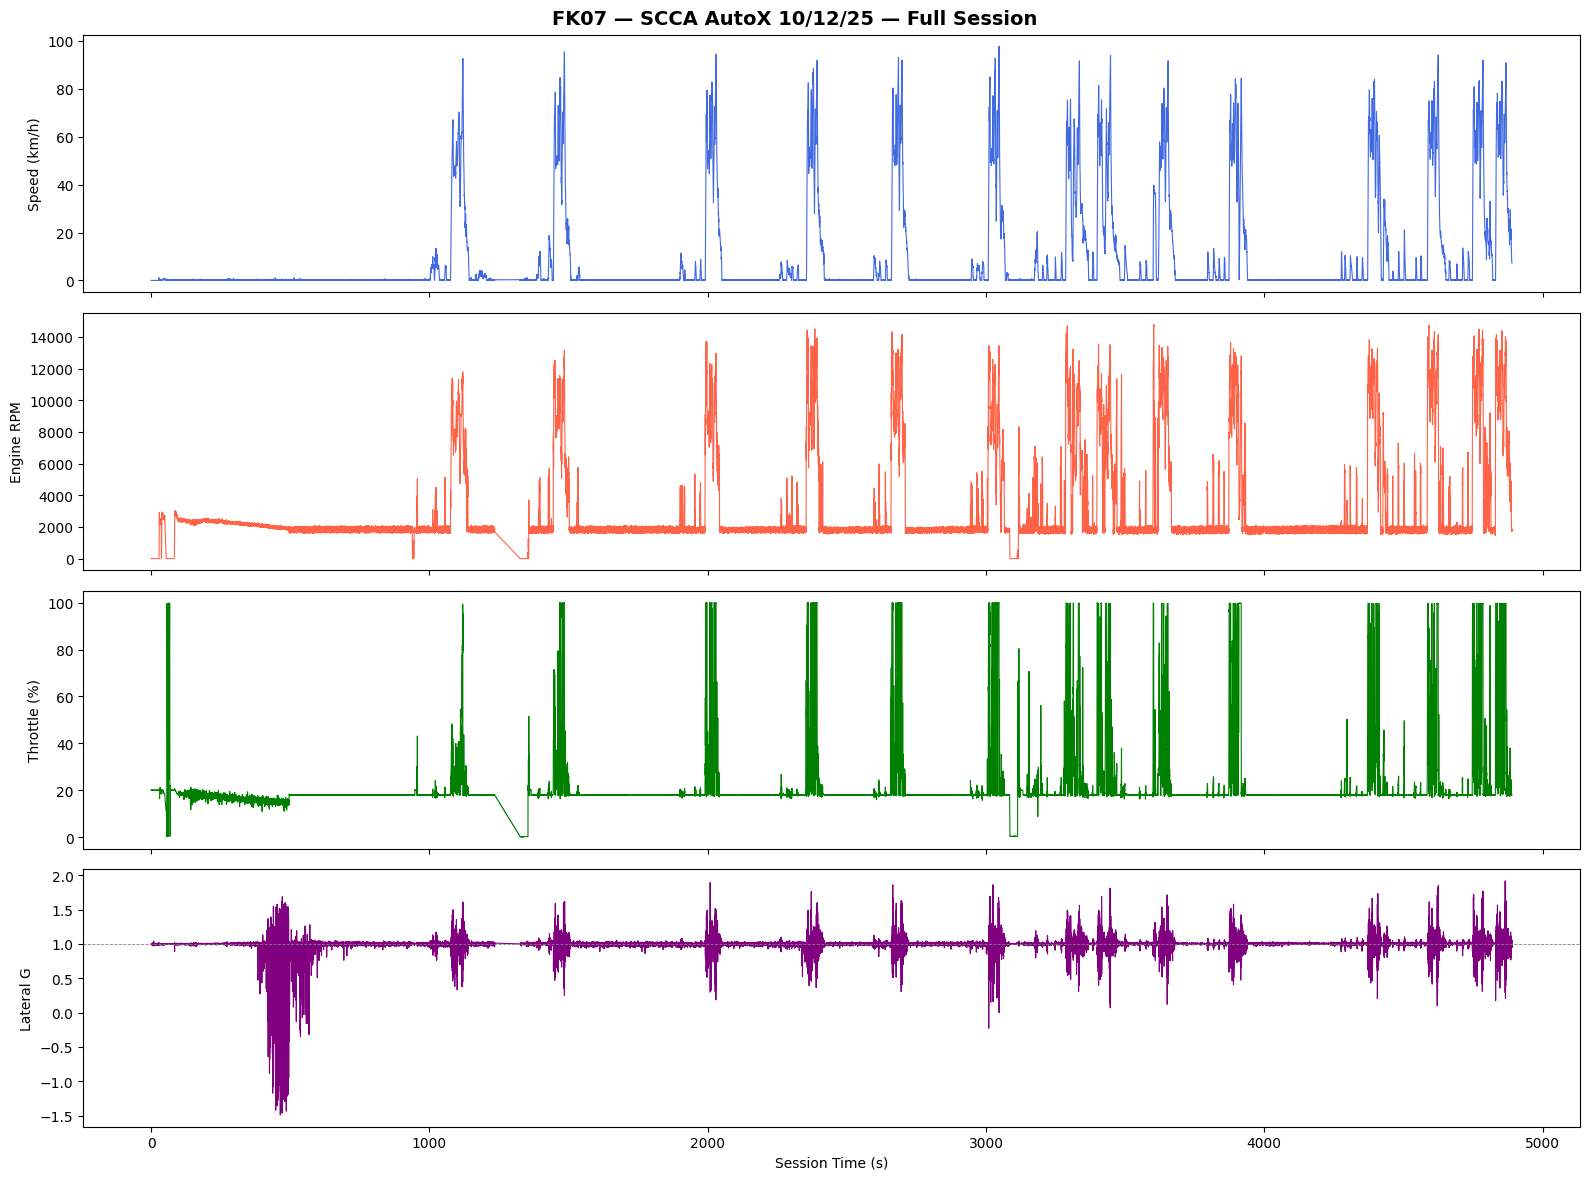

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
fig.suptitle('FK07 — SCCA AutoX 10/12/25 — Full Session', fontsize=14, fontweight='bold')

axes[0].plot(df['xtime'], df['gps_speed_kmh'], color='royalblue', lw=0.8)
axes[0].set_ylabel('Speed (km/h)')

axes[1].plot(df['xtime'], df['engine_speed_rpm'], color='tomato', lw=0.8)
axes[1].set_ylabel('Engine RPM')

axes[2].plot(df['xtime'], df['throttle_pct'], color='green', lw=0.8)
axes[2].set_ylabel('Throttle (%)')

axes[3].plot(df['xtime'], df['az'], color='purple', lw=0.8)
axes[3].axhline(1.0, color='gray', linestyle='--', lw=0.6)
axes[3].set_ylabel('Lateral G')
axes[3].set_xlabel('Session Time (s)')

plt.tight_layout()
plt.show()

## Lap Times

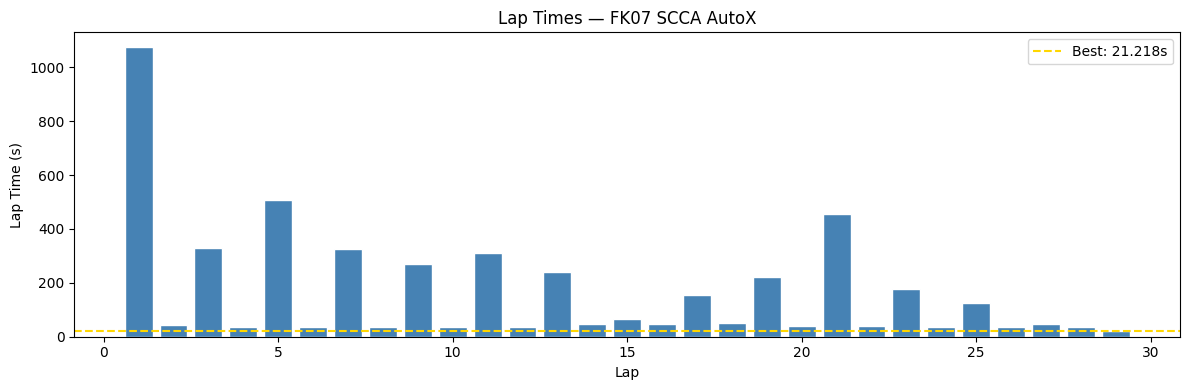

 lap  lap_time_s
   1    1075.700
   2      44.143
   3     327.403
   4      37.309
   5     508.318
   6      36.886
   7     326.797
   8      35.938
   9     269.451
  10      35.665
  11     311.878
  12      36.756
  13     241.500
  14      47.181
  15      65.300
  16      46.275
  17     155.229
  18      51.653
  19     220.895
  20      41.626
  21     456.625
  22      39.251
  23     175.390
  24      36.198
  25     125.410
  26      35.539
  27      47.519
  28      35.504
  29      21.218


In [5]:
lap_times = df.groupby('lap_number')['laptime_s'].max().reset_index()
lap_times.columns = ['lap', 'lap_time_s']
lap_times = lap_times[lap_times['lap_time_s'] > 5]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(lap_times['lap'], lap_times['lap_time_s'], color='steelblue', edgecolor='white')
ax.axhline(lap_times['lap_time_s'].min(), color='gold', linestyle='--',
           label=f"Best: {lap_times['lap_time_s'].min():.3f}s")
ax.set_xlabel('Lap')
ax.set_ylabel('Lap Time (s)')
ax.set_title('Lap Times — FK07 SCCA AutoX')
ax.legend()
plt.tight_layout()
plt.show()
print(lap_times.to_string(index=False))

## Lap Comparison — Speed Trace

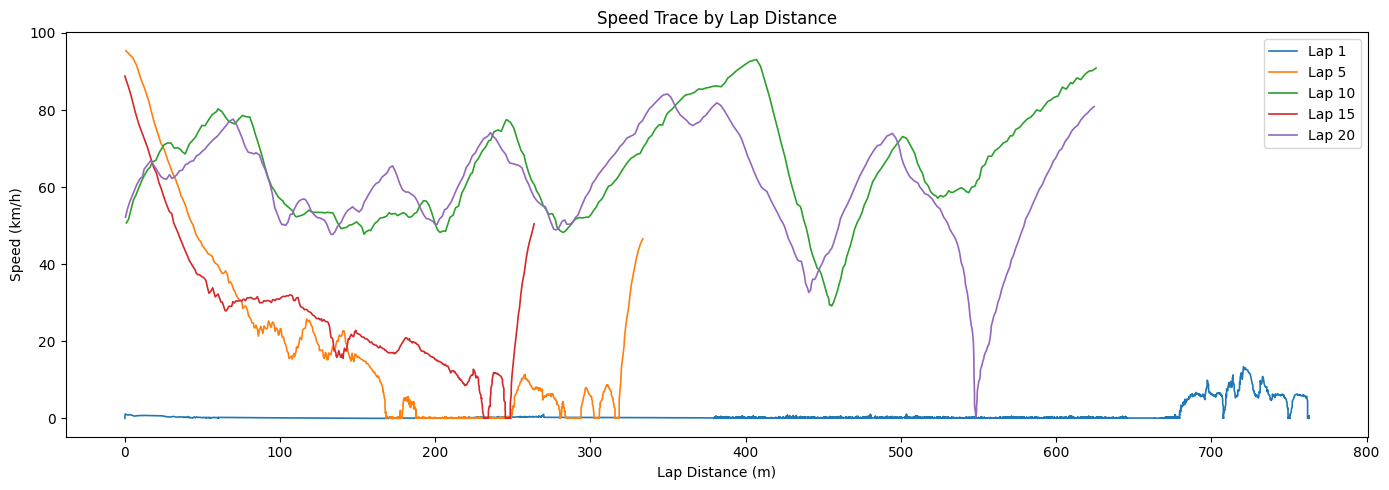

In [6]:
LAPS_TO_COMPARE = [1, 5, 10, 15, 20]

fig, ax = plt.subplots(figsize=(14, 5))
for lap in LAPS_TO_COMPARE:
    lap_df = df[df['lap_number'] == lap].copy()
    if lap_df.empty:
        continue
    ax.plot(lap_df['lapdist_m'], lap_df['gps_speed_kmh'], label=f'Lap {lap}', lw=1.2)

ax.set_xlabel('Lap Distance (m)')
ax.set_ylabel('Speed (km/h)')
ax.set_title('Speed Trace by Lap Distance')
ax.legend()
plt.tight_layout()
plt.show()

## Steering Angle vs Speed (Handling Map)

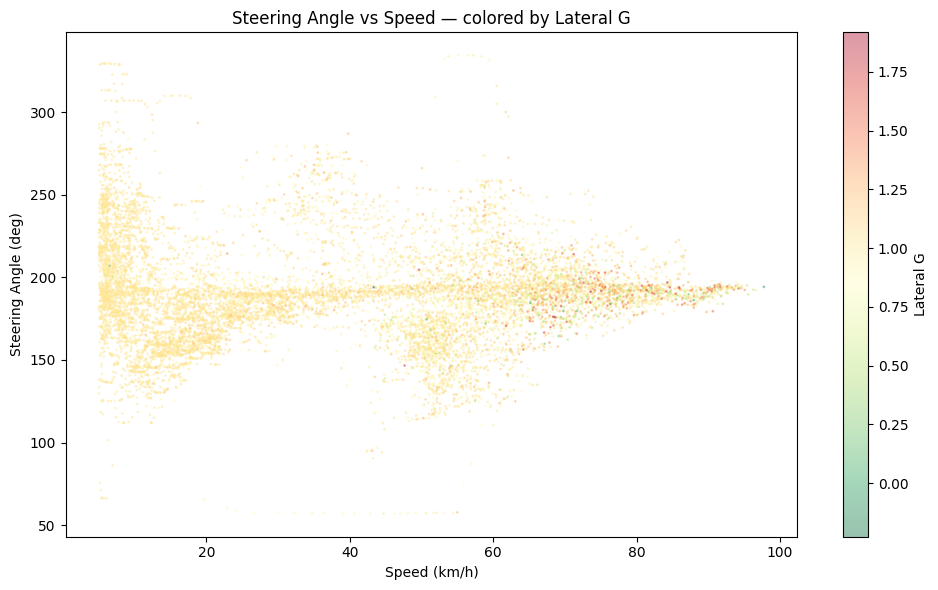

In [7]:
moving = df[df['gps_speed_kmh'] > 5].copy()

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(moving['gps_speed_kmh'], moving['str_whl_angle_deg'],
                c=moving['az'], cmap='RdYlGn_r', s=1, alpha=0.4)
plt.colorbar(sc, label='Lateral G')
ax.set_xlabel('Speed (km/h)')
ax.set_ylabel('Steering Angle (deg)')
ax.set_title('Steering Angle vs Speed — colored by Lateral G')
plt.tight_layout()
plt.show()

## Coolant Temperature Over Session

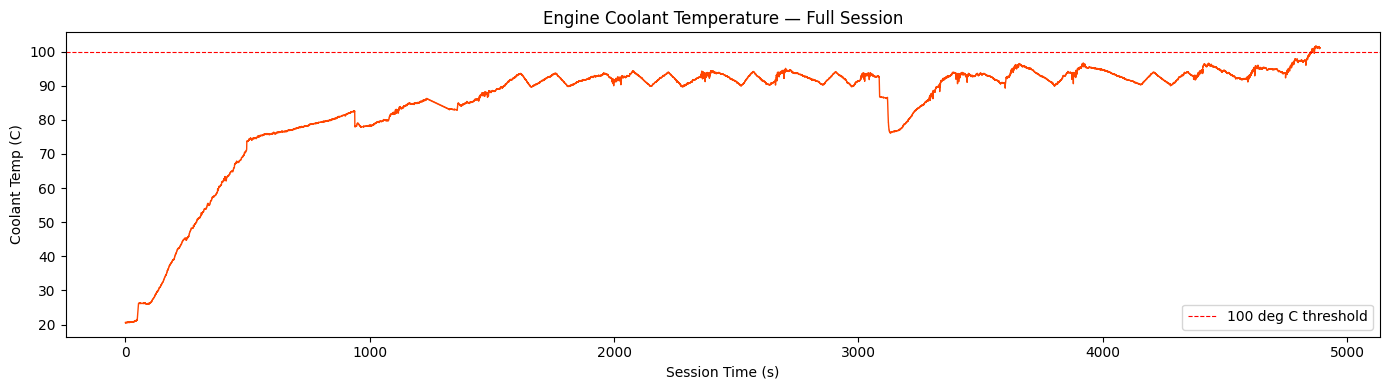

In [8]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['xtime'], df['coolant_temp_c'], color='orangered', lw=1)
ax.axhline(100, color='red', linestyle='--', lw=0.8, label='100 deg C threshold')
ax.set_xlabel('Session Time (s)')
ax.set_ylabel('Coolant Temp (C)')
ax.set_title('Engine Coolant Temperature — Full Session')
ax.legend()
plt.tight_layout()
plt.show()